In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import binned_statistic
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [2]:
FITS_PATH = '/Users/carlimankowski/Desktop/DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits'
hdul = fits.open(FITS_PATH)
data = hdul[1].data
hdul.close()
print(f'Total stars: {len(data):,}')

mask = (
    (data['teff'] > 3700) & (data['teff'] < 5300) &
    (data['logg'] > 0.9)  & (data['logg'] < 3.3)  &
    (data['m_h_atm'] > -2.0) & (data['m_h_atm'] < 0.6) &
    (~data['flag_bad']) &
    np.isfinite(data['fe_h']) & (data['fe_h'] != -9999) &
    np.isfinite(data['c_h']) & (data['c_h'] != -9999) &
    np.isfinite(data['n_h']) & (data['n_h'] != -9999)
)
d = data[mask]
print(f'After cuts: {mask.sum():,} stars')

R_SUN, Z_SUN = 8.122, 0.0208
dist  = d['r_med_geo'] / 1000.0
l_rad = np.radians(d['l']); b_rad = np.radians(d['b'])
x_gc  = dist * np.cos(b_rad) * np.cos(l_rad)
y_gc  = dist * np.cos(b_rad) * np.sin(l_rad)
Rgal  = np.sqrt((x_gc - R_SUN)**2 + y_gc**2)
Zgal  = dist * np.sin(b_rad) + Z_SUN

Total stars: 388,529


After cuts: 351,995 stars


In [ ]:
def running_stat(x, y, n_bins=25, x_range=None, stat='median'):
    result, edges, _ = binned_statistic(x, y, statistic=stat, bins=n_bins, range=x_range)
    return 0.5 * (edges[:-1] + edges[1:]), result

def running_percentile(x, y, pct, n_bins=25, x_range=None):
    return running_stat(x, y, n_bins=n_bins, x_range=x_range,
                        stat=lambda v: np.nanpercentile(v, pct))

ALL_NN_COLS = [
    'ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age',
    'HK_AP3_training_Age', 'RF_AP3_training_Age', 'EP_AP3_training_Age',
    'LM_AK2_training_Age', 'NM_AK2_training_Age', 'EP_AK2_training_Age',
    'ZS_TESS_training_Age', 'HK_TESS_training_Age', 'LM_TESS_training_Age',
]

C_AP2  = '#F50000'
C_AP3  = 'b'
C_AK2  = 'c'
C_TESS = '#A32CDC'

SHADES_AP2  = ['#A30000', '#F50000', '#FF7373']
SHADES_AP3  = ['#000080', '#0000FF', '#7373FF']
SHADES_AK2  = ['#008888', '#00CCCC', '#88FFFF']
SHADES_TESS = ['#5C148A', '#A32CDC', '#C77FE8']

TASKS = [
    (14, 'Leung2023_Age',       'Leung+23',
     ['ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age'],
     ['ZS (AP2)', 'RF (AP2)', 'NM (AP2)'], SHADES_AP2),
    (15, 'Mackereth2019_Age',   'Mackereth+19',
     ['ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age'],
     ['ZS (AP2)', 'RF (AP2)', 'NM (AP2)'], SHADES_AP2),
    (16, 'StoneMartinez2025_Age', 'Stone-Martinez+25',
     ['HK_AP3_training_Age', 'RF_AP3_training_Age', 'EP_AP3_training_Age'],
     ['HK (AP3)', 'RF (AP3)', 'EP (AP3)'], SHADES_AP3),
    (17, 'StoneMartinez2025_Age', 'Stone-Martinez+25',
     ['LM_AK2_training_Age', 'NM_AK2_training_Age', 'EP_AK2_training_Age'],
     ['LM (AK2)', 'NM (AK2)', 'EP (AK2)'], SHADES_AK2),
]

BEST_COL = 'HK_AP3_training_Age'
AGE_BINS = [
    (0,  4,  '<4 Gyr',    '#440154'),
    (4,  6,  '4-6 Gyr',   '#31688e'),
    (6,  8,  '6-8 Gyr',   '#35b779'),
    (8,  10, '8-10 Gyr',  '#fde725'),
    (10, 12, '10-12 Gyr', '#f58231'),
    (12, 99, '>12 Gyr',   '#e6194b'),
]

---
## Figure 5 — 1:1 Plots: AP3 NNs vs Literature Ages
2 rows (Leung+23, Stone-Martinez+25) × 4 cols (3 AP3 NN methods + residual histograms).

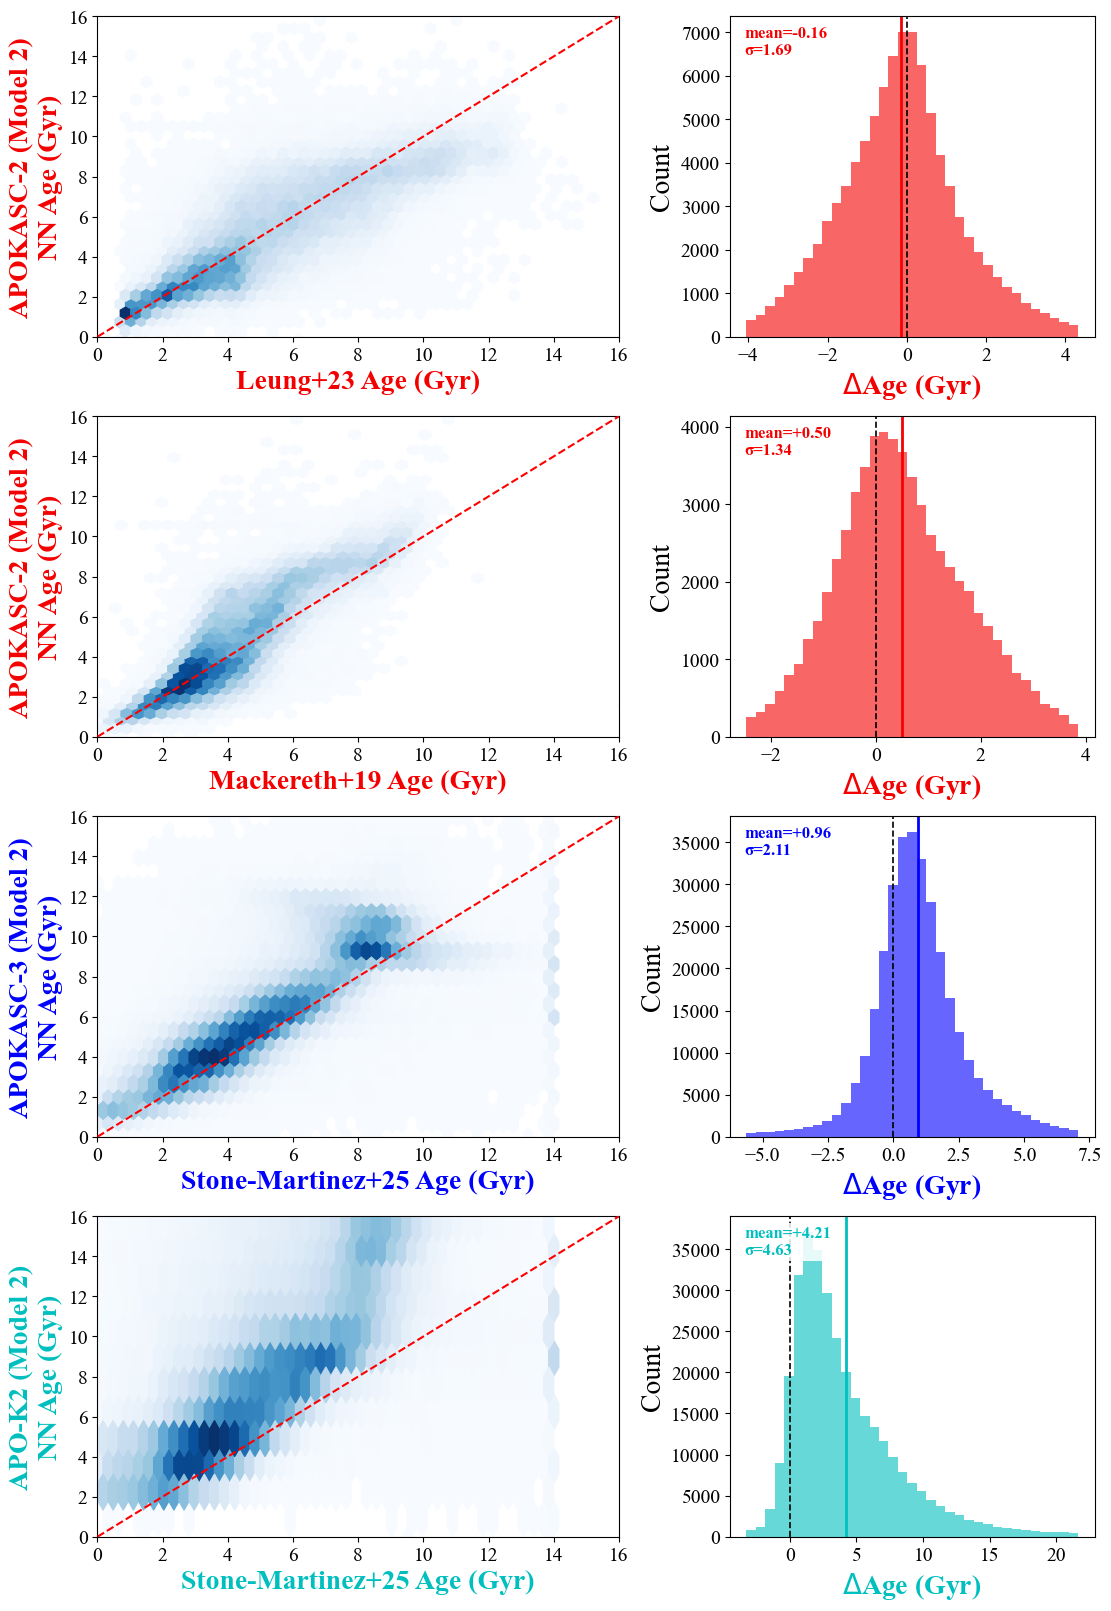

In [4]:
FIG5_ROWS = [
    ('Leung2023_Age',         'Leung+23',          'ZS_AP2_training_Age',  'APOKASC-2 (Model 2)',  C_AP2),
    ('Mackereth2019_Age',     'Mackereth+19',      'ZS_AP2_training_Age',  'APOKASC-2 (Model 2)',  C_AP2),
    ('StoneMartinez2025_Age', 'Stone-Martinez+25', 'HK_AP3_training_Age',  'APOKASC-3 (Model 2)',  C_AP3),
    ('StoneMartinez2025_Age', 'Stone-Martinez+25', 'LM_AK2_training_Age',  'APO-K2 (Model 2)',     C_AK2),
]

fig, axes = plt.subplots(4, 2, figsize=(11, 16), constrained_layout=True,
                         gridspec_kw={'width_ratios': [2, 1.4]})

for row, (lit_col, lit_label, nn_col, nn_label, color) in enumerate(FIG5_ROWS):
    ax_sc, ax_hi = axes[row, 0], axes[row, 1]

    valid = (np.isfinite(d[lit_col]) & (d[lit_col] != -9999) & (d[lit_col] > 0) &
             np.isfinite(d[nn_col])  & (d[nn_col]  != -9999))
    lit_age = d[lit_col][valid]
    nn_age  = d[nn_col][valid]
    offset  = nn_age - lit_age
    finite  = offset[np.isfinite(offset)]

    ax_sc.hexbin(lit_age, nn_age, gridsize=45, cmap='Blues', mincnt=1, rasterized=True)
    ax_sc.plot([0, 16], [0, 16], 'r--', lw=1.5, zorder=5)
    ax_sc.set_xlim(0, 16); ax_sc.set_ylim(0, 16)
    ax_sc.set_xlabel(f'{lit_label} Age (Gyr)', color=color, fontweight='bold')
    ax_sc.set_ylabel(f'{nn_label}\nNN Age (Gyr)', color=color, fontweight='bold')

    lo, hi = np.nanpercentile(finite, 1), np.nanpercentile(finite, 99)
    inside = finite[(finite >= lo) & (finite <= hi)]
    ax_hi.hist(inside, bins=35, orientation='vertical',
               color=color, alpha=0.6, edgecolor='none', rasterized=True)
    mean_v = np.nanmean(finite); std_v = np.nanstd(finite)
    ax_hi.axvline(mean_v, color=color, lw=2, ls='-')
    ax_hi.axvline(0, color='k', lw=1.2, ls='--')
    ax_hi.set_xlabel(r'$\Delta$Age (Gyr)', color=color, fontweight='bold')
    ax_hi.set_ylabel('Count')
    ax_hi.text(0.04, 0.97, f'mean={mean_v:+.2f}\nσ={std_v:.2f}',
               transform=ax_hi.transAxes, fontsize=12, va='top',
               color=color, fontweight='bold',
               bbox=dict(fc='white', alpha=0.85, ec='none', pad=2))

plt.savefig('figure5_onetoone.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 6 — Training-Set Age Differences vs Stellar Parameters
3 rows (AP2-AP3, AK2-AP3, TESS-AP3) × 3 cols ($T_{\rm eff}$, log g, [M/H]). AP3 is the baseline; ages restricted to 0.1–14.5 Gyr.

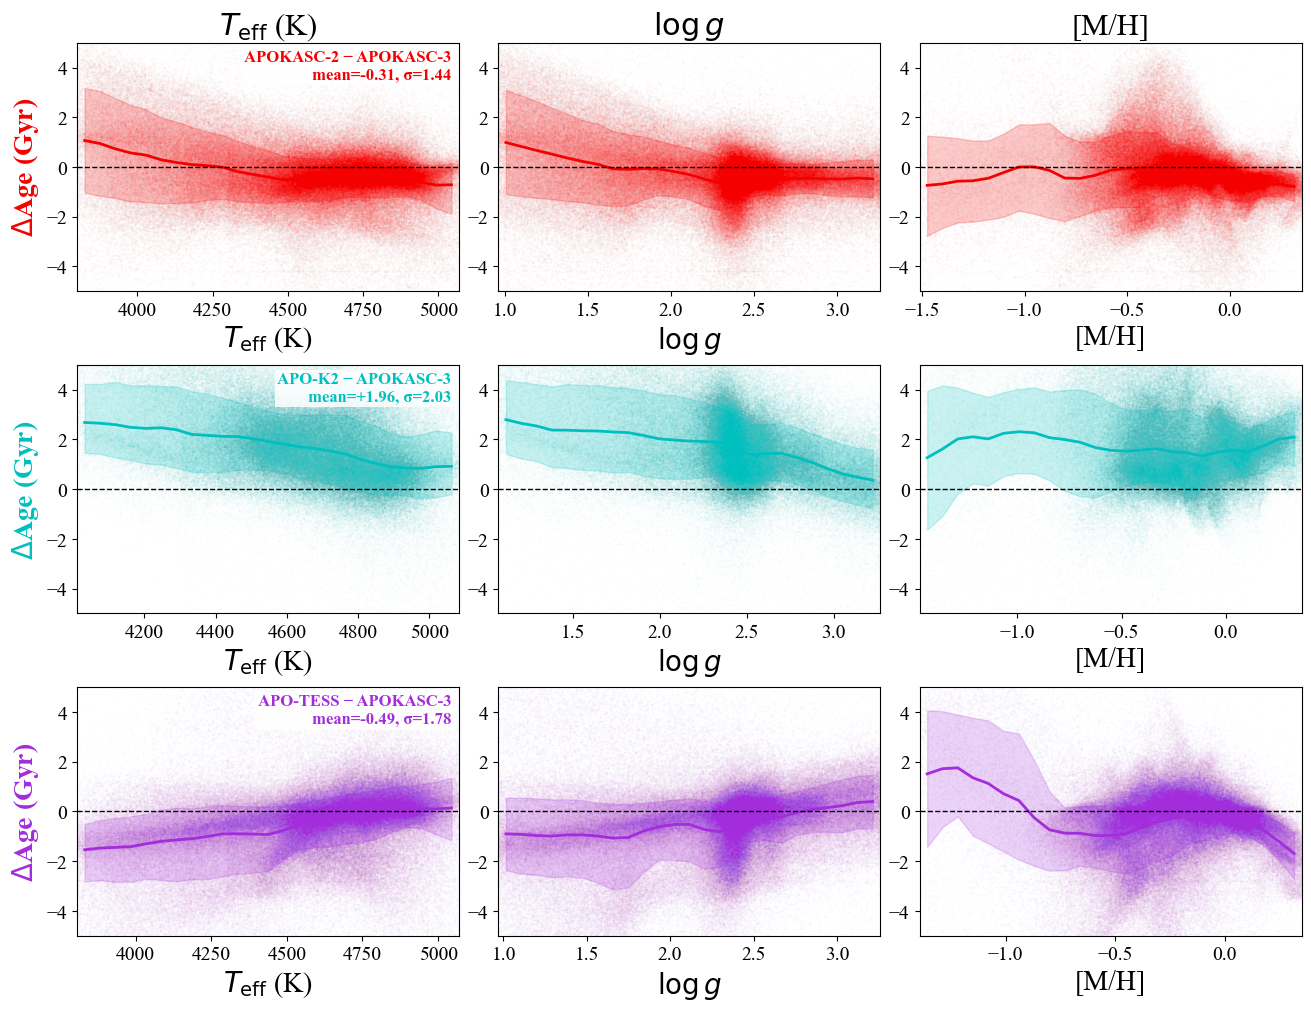

In [5]:
REP = {
    'TESS': 'ZS_TESS_training_Age',
    'AP2':  'ZS_AP2_training_Age',
    'AP3':  'HK_AP3_training_Age',
    'AK2':  'LM_AK2_training_Age',
}
FULL_NAMES = {'TESS': 'APO-TESS', 'AP2': 'APOKASC-2', 'AP3': 'APOKASC-3', 'AK2': 'APO-K2'}
BASE = 'AP3'
PAIRS = [('AP2', C_AP2), ('AK2', C_AK2), ('TESS', C_TESS)]
FIG6_PARAMS = ['teff',      'logg',    'm_h_atm']
FIG6_LABELS = [r'$T_{\rm eff}$ (K)', r'$\log g$', r'[M/H]']
N_BINS = 25
AGE_LO, AGE_HI = 0.1, 14.5
OFFSET_MAX = 5.0

base_col = REP[BASE]; base_full = FULL_NAMES[BASE]

fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)

for row, (other, color) in enumerate(PAIRS):
    other_col = REP[other]; other_full = FULL_NAMES[other]
    both_valid = (np.isfinite(d[base_col])  & (d[base_col]  != -9999) &
                  np.isfinite(d[other_col]) & (d[other_col] != -9999) &
                  (d[base_col]  >= AGE_LO) & (d[base_col]  <= AGE_HI) &
                  (d[other_col] >= AGE_LO) & (d[other_col] <= AGE_HI))

    for col_idx, (param, plabel) in enumerate(zip(FIG6_PARAMS, FIG6_LABELS)):
        ax = axes[row, col_idx]
        mask = both_valid & np.isfinite(d[param])
        x_full = d[param][mask]
        offset_full = d[other_col][mask] - d[base_col][mask]

        keep = np.abs(offset_full) <= OFFSET_MAX
        x = x_full[keep]; offset = offset_full[keep]

        x_range = (np.nanpercentile(x, 1), np.nanpercentile(x, 99))

        ax.scatter(x, offset, c=color, alpha=0.03, s=0.1, rasterized=True)

        xmean, ymean = running_stat(x, offset, n_bins=N_BINS, x_range=x_range, stat='mean')
        _, y16 = running_percentile(x, offset, 16, n_bins=N_BINS, x_range=x_range)
        _, y84 = running_percentile(x, offset, 84, n_bins=N_BINS, x_range=x_range)
        ok = np.isfinite(ymean)
        ax.plot(xmean[ok], ymean[ok], color=color, lw=2)
        ax.fill_between(xmean[ok], y16[ok], y84[ok], color=color, alpha=0.2, rasterized=True)

        ax.axhline(0, color='k', lw=1.0, ls='--', zorder=5)
        ax.set_xlabel(plabel)
        ax.set_xlim(x_range)
        ax.set_ylim(-OFFSET_MAX, OFFSET_MAX)

        if col_idx == 0:
            mean_v = np.nanmean(offset_full[np.isfinite(offset_full)])
            std_v  = np.nanstd(offset_full[np.isfinite(offset_full)])
            ax.set_ylabel(r'$\Delta$Age (Gyr)', color=color, fontweight='bold')
            ax.text(0.98, 0.97, f'{other_full} − {base_full}\nmean={mean_v:+.2f}, σ={std_v:.2f}',
                    transform=ax.transAxes, fontsize=12, ha='right', va='top',
                    color=color, fontweight='bold',
                    bbox=dict(fc='white', alpha=0.85, ec='none', pad=2))

for col_idx, plabel in enumerate(FIG6_LABELS):
    axes[0, col_idx].set_title(plabel)

plt.savefig('figure6_training_diffs.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 7 — Cluster Age Validation (Model 2 per training set)
4 rows: AP2, AP3, AK2, TESS Model-2 networks. Mean + σ in the histogram are computed from open clusters only (GC stars distort the fit).

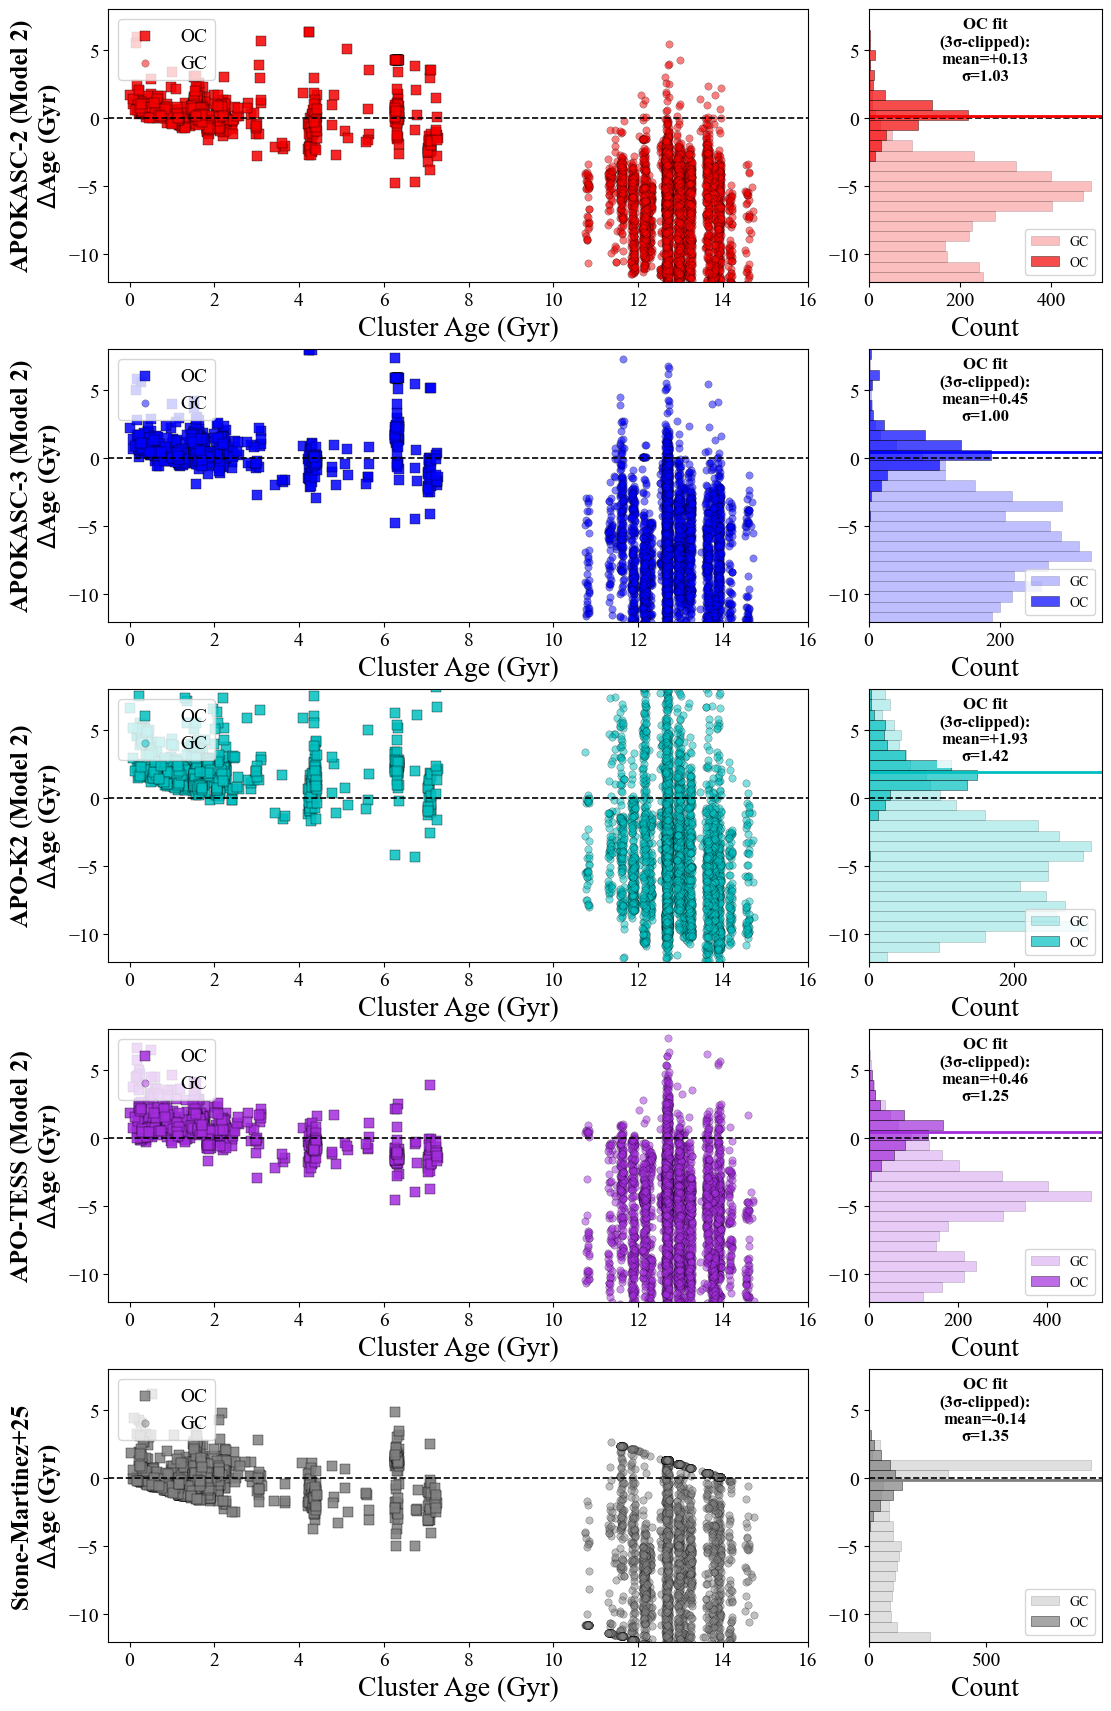

In [6]:
from astropy.stats import sigma_clipped_stats

METHODS_FIG7 = [
    ('APOKASC-2 (Model 2)',  'ZS_AP2_training_Age',  C_AP2),
    ('APOKASC-3 (Model 2)',  'HK_AP3_training_Age',  C_AP3),
    ('APO-K2 (Model 2)',     'LM_AK2_training_Age',  C_AK2),
    ('APO-TESS (Model 2)',   'ZS_TESS_training_Age', C_TESS),
    ('Stone-Martinez+25',    'StoneMartinez2025_Age','grey'),
]

oc_mask = np.isfinite(data['Cluster_CG20_Age']) & (data['Cluster_CG20_Age'] > 0)
gc_mask = np.isfinite(data['Cluster_D07_Age'])  & (data['Cluster_D07_Age'] > 0)
oc = data[oc_mask]; gc = data[gc_mask]

Y_RANGE = (-12, 8)
N = len(METHODS_FIG7)
fig, axes = plt.subplots(N, 2, figsize=(11, 3.4 * N), constrained_layout=True,
                         gridspec_kw={'width_ratios': [3, 1]})

for row, (label, nn_col, color) in enumerate(METHODS_FIG7):
    ax_sc, ax_hi = axes[row, 0], axes[row, 1]
    oc_off, gc_off = None, None

    oc_valid = np.isfinite(oc[nn_col]) & (oc[nn_col] != -9999)
    if oc_valid.sum() > 0:
        oc_clust = oc['Cluster_CG20_Age'][oc_valid]
        oc_off   = oc[nn_col][oc_valid] - oc_clust
        jit = np.random.default_rng(42).uniform(-0.05, 0.05, size=len(oc_clust))
        ax_sc.scatter(oc_clust + jit, oc_off, c=color, marker='s', s=45,
                      alpha=0.85, edgecolors='k', linewidths=0.3, label='OC', rasterized=True)

    gc_valid = np.isfinite(gc[nn_col]) & (gc[nn_col] != -9999)
    if gc_valid.sum() > 0:
        gc_clust = gc['Cluster_D07_Age'][gc_valid]
        gc_off   = gc[nn_col][gc_valid] - gc_clust
        jit = np.random.default_rng(43).uniform(-0.05, 0.05, size=len(gc_clust))
        ax_sc.scatter(gc_clust + jit, gc_off, c=color, marker='o', s=28,
                      alpha=0.5, edgecolors='k', linewidths=0.3, label='GC', rasterized=True)

    ax_sc.axhline(0, color='k', lw=1.2, ls='--')
    ax_sc.set_xlabel('Cluster Age (Gyr)'); ax_sc.set_xlim(-0.5, 16)
    ax_sc.set_ylim(Y_RANGE)
    ax_sc.set_ylabel(f'{label}\n' + r'$\Delta$Age (Gyr)', color='black', fontweight='bold', fontsize=18)
    ax_sc.legend(loc='upper left', fontsize=14)

    if oc_off is not None and len(oc_off) > 0:
        oc_finite = oc_off[np.isfinite(oc_off)]
        gc_finite = gc_off[np.isfinite(gc_off)] if gc_off is not None else np.array([])
        bins = np.linspace(Y_RANGE[0], Y_RANGE[1], 28)

        if len(gc_finite) > 0:
            ax_hi.hist(gc_finite, bins=bins, orientation='horizontal',
                       color=color, alpha=0.25, edgecolor='k', linewidth=0.4, label='GC',
                       rasterized=True)
        ax_hi.hist(oc_finite, bins=bins, orientation='horizontal',
                   color=color, alpha=0.7, edgecolor='k', linewidth=0.4, label='OC',
                   rasterized=True)

        oc_mean, oc_med, oc_std = sigma_clipped_stats(oc_finite, sigma=3, maxiters=5)

        ax_hi.axhline(0, color='k', lw=1.2, ls='--')
        ax_hi.axhline(oc_mean, color=color, lw=2, ls='-')
        ax_hi.set_xlabel('Count')
        ax_hi.text(0.5, 0.97,
                   f'OC fit\n(3σ-clipped):\nmean={oc_mean:+.2f}\nσ={oc_std:.2f}',
                   transform=ax_hi.transAxes, fontsize=12,
                   ha='center', va='top', color='black', fontweight='bold',
                   bbox=dict(fc='white', alpha=0.85, ec='none', pad=2))
        ax_hi.legend(loc='lower right', fontsize=10)
        ax_hi.set_ylim(Y_RANGE)

plt.savefig('figure7_cluster_validation.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 8 — Per-Star Age Scatter (split into 3 subfigures)
σ_age computed across Model 2 trained on AP3, AK2, TESS (AP2 excluded — biased predictions).
- 8a: Kiel diagram + chemical plane (zoomed)
- 8b: violin plot by stellar population
- 8c: σ_age vs $R_\mathrm{gal}$, [M/H], [α/M] (y-axis capped at 5 Gyr, [α/M] cropped to bulk)

In [ ]:
SCATTER_COLS = ['HK_AP3_training_Age', 'ZS_AP2_training_Age', 'ZS_TESS_training_Age']
nn_stack = np.column_stack([d[col] for col in SCATTER_COLS]).astype(float)
nn_stack[nn_stack == -9999] = np.nan
age_std = np.nanstd(nn_stack, axis=1)
good = np.sum(np.isfinite(nn_stack), axis=1) >= 3

ap3_age = d['HK_AP3_training_Age'].astype(float)
ap3_age[ap3_age == -9999] = np.nan

fractional = np.full_like(age_std, np.nan, dtype=float)
ok_frac = np.isfinite(ap3_age) & (ap3_age > 0.5)
fractional[ok_frac] = age_std[ok_frac] / ap3_age[ok_frac]

std_g  = age_std[good]
frac_g = fractional[good]
teff_g = d['teff'][good].astype(float)
logg_g = d['logg'][good].astype(float)
mh_g   = d['m_h_atm'][good].astype(float)
alph_g = d['alpha_m_atm'][good].astype(float)
feh_g  = d['fe_h'][good].astype(float)
Rgal_g = Rgal[good]
ap3_g  = ap3_age[good]


fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for row_i, (metric, label_unit, vmax_pct) in enumerate([
    (std_g,  r'$\sigma_{\rm age}$ (Gyr)',                     95),
    (frac_g, r'$\sigma_{\rm age} / \mathrm{Age}_{\rm AP3}$',   95),
]):
    vmax = np.nanpercentile(metric, vmax_pct)
    ax_kiel, ax_chem, ax_agem = axes[row_i]

    sc1 = ax_kiel.scatter(teff_g, logg_g, c=metric, cmap='inferno', vmin=0, vmax=vmax,
                          s=0.2, alpha=0.8, rasterized=True)
    ax_kiel.invert_xaxis(); ax_kiel.invert_yaxis()
    ax_kiel.set_xlabel(r'$T_{\rm eff}$ (K)'); ax_kiel.set_ylabel(r'$\log g$')
    plt.colorbar(sc1, ax=ax_kiel, label=label_unit)

    ok_chem = np.isfinite(feh_g) & np.isfinite(alph_g) & np.isfinite(metric)
    sc2 = ax_chem.scatter(feh_g[ok_chem], alph_g[ok_chem], c=metric[ok_chem],
                          cmap='inferno', vmin=0, vmax=vmax, s=0.3, alpha=0.85, rasterized=True)
    ax_chem.set_xlabel('[Fe/H]'); ax_chem.set_ylabel(r'[$\alpha$/M]')
    ax_chem.set_xlim(-1.5, 0.5); ax_chem.set_ylim(-0.10, 0.35)
    plt.colorbar(sc2, ax=ax_chem, label=label_unit)

    ok_am = np.isfinite(ap3_g) & np.isfinite(mh_g) & np.isfinite(metric) & (ap3_g >= 0) & (ap3_g <= 14.5)
    sc3 = ax_agem.scatter(mh_g[ok_am], ap3_g[ok_am], c=metric[ok_am],
                          cmap='inferno', vmin=0, vmax=vmax, s=0.3, alpha=0.85, rasterized=True)
    ax_agem.set_xlabel('[M/H]'); ax_agem.set_ylabel('Age (Gyr, APOKASC-3 Model 2)')
    ax_agem.set_xlim(-2.0, 0.6); ax_agem.set_ylim(0, 14.5)
    plt.colorbar(sc3, ax=ax_agem, label=label_unit)

plt.savefig('figure8a_age_scatter_planes.pdf', dpi=600, bbox_inches='tight')
plt.show()


POPS = [
    ('High-α',                'α/M > 0.12',                              alph_g > 0.12),
    ('Low-α metal-rich',      '[M/H] > −0.2,\nα/M ≤ 0.12',                (alph_g <= 0.12) & (mh_g > -0.2)),
    ('Low-α metal-poor',      '−0.8 < [M/H] ≤ −0.2,\nα/M ≤ 0.12',         (alph_g <= 0.12) & (mh_g > -0.8) & (mh_g <= -0.2)),
    ('Very metal-poor',       '[M/H] < −0.8',                             mh_g < -0.8),
    ('Inner galaxy',          r'$R_{\rm gal}$ < 4 kpc',                   Rgal_g < 4.0),
    ('Outer galaxy',          r'$R_{\rm gal}$ > 10 kpc',                  Rgal_g > 10.0),
]

fig, ax = plt.subplots(1, 1, figsize=(15, 7.5), constrained_layout=True)
pop_data, pop_short, pop_def = [], [], []
for name, definition, pmask in POPS:
    vals = frac_g[pmask & np.isfinite(frac_g)]
    pop_data.append(vals)
    pop_short.append(name)
    pop_def.append(definition)

parts = ax.violinplot(pop_data, showmedians=False, showmeans=True, showextrema=False, widths=0.75)
for pc in parts['bodies']:
    pc.set_alpha(0.5)
    pc.set_rasterized(True)
parts['cmeans'].set_color('k')
ax.set_xticks(range(1, len(pop_short) + 1))
ax.set_xticklabels(pop_short, fontsize=20, fontweight='bold')
ax.set_ylabel(r'$\sigma_{\rm age} / \mathrm{Age}_{\rm AP3}$', fontsize=20)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', pad=8)

for i, definition in enumerate(pop_def, start=1):
    ax.text(i, 0.93, definition,
            transform=ax.transData,
            ha='center', va='top', fontsize=18, rotation=15,
            color='dimgray', fontweight='bold',
            bbox=dict(fc='white', alpha=0.85, ec='none', pad=2))

plt.savefig('figure8b_violin_populations_frac.pdf', dpi=600, bbox_inches='tight')
plt.show()


SIGMA_YMAX = 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
for ax, x, xl, xlim in [
    (axes[0], Rgal_g, r'$R_{\rm gal}$ (kpc)',  (0, 18)),
    (axes[1], mh_g,   '[M/H]',                  (-2.0, 0.6)),
    (axes[2], alph_g, r'[$\alpha$/M]',          (-0.10, 0.30)),
]:
    ok = np.isfinite(x) & np.isfinite(frac_g) & (x >= xlim[0]) & (x <= xlim[1])
    ax.hexbin(x[ok], frac_g[ok], gridsize=55, cmap='Blues', mincnt=1,
              extent=(xlim[0], xlim[1], 0, SIGMA_YMAX), rasterized=True)
    xmean, ymean = running_stat(x[ok], frac_g[ok], n_bins=25, x_range=xlim, stat='mean')
    ok2 = np.isfinite(ymean)
    ax.plot(xmean[ok2], ymean[ok2], 'r-', lw=2, label='running mean')
    ax.set_xlabel(xl); ax.set_ylabel(r'$\sigma_{\rm age} / \mathrm{Age}_{\rm AP3}$')
    ax.set_xlim(xlim); ax.set_ylim(0, SIGMA_YMAX)
    ax.legend(loc='upper right')

plt.savefig('figure8c_age_scatter_vs_params_frac.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 9 — [α/M] vs [M/H] in Age Bins (+ α-age correlation)
2×4 grid: 7 age bins (<2, 2-4, 4-6, 6-8, 8-10, 10-12, >12 Gyr) + 8th panel showing [α/M] vs Age across the full sample.

In [ ]:
ages  = d[BEST_COL].astype(float); ages[ages == -9999] = np.nan
mh    = d['m_h_atm'].astype(float)
alpha = d['alpha_m_atm'].astype(float)

AGE_BINS_FIG9 = [
    (0,  2,  '<2 Gyr'),
    (2,  4,  '2-4 Gyr'),
    (4,  6,  '4-6 Gyr'),
    (6,  8,  '6-8 Gyr'),
    (8,  10, '8-10 Gyr'),
    (10, 12, '10-12 Gyr'),
    (12, 99, '>12 Gyr'),
]

def make_fig9(color_by, cbar_label, fname, vmin=None, vmax=None,
              n_in_title=False, stat='mean'):
    fig, axes = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)
    axes_flat = axes.flatten()

    for ax, (lo, hi, label) in zip(axes_flat[:7], AGE_BINS_FIG9):
        if color_by == 'Nstars':
            in_bin = (ages >= lo) & (ages < hi) & np.isfinite(mh) & np.isfinite(alpha)
            hb = ax.hexbin(mh[in_bin], alpha[in_bin],
                           gridsize=50, cmap='viridis', mincnt=1, rasterized=True)
        else:
            in_bin = (ages >= lo) & (ages < hi) & np.isfinite(mh) & np.isfinite(alpha) & np.isfinite(Rgal)
            hb = ax.hexbin(mh[in_bin], alpha[in_bin], C=Rgal[in_bin],
                           reduce_C_function=np.mean,
                           gridsize=50, cmap='viridis', mincnt=1,
                           vmin=vmin, vmax=vmax, rasterized=True)
        ax.set_xlabel('[M/H]'); ax.set_ylabel(r'[$\alpha$/M]')
        ax.set_xlim(-2.0, 0.6); ax.set_ylim(-0.1, 0.4)
        if n_in_title:
            ax.set_title(f'{label}  (N={in_bin.sum():,})')
        else:
            ax.set_title(label)
            ax.text(0.04, 0.96, f'N={in_bin.sum():,}',
                    transform=ax.transAxes, fontsize=11, va='top', ha='left',
                    bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
        plt.colorbar(hb, ax=ax, label=cbar_label)

    ax = axes_flat[7]
    if color_by == 'Nstars':
        ok = np.isfinite(ages) & np.isfinite(alpha)
        hb = ax.hexbin(ages[ok], alpha[ok],
                       gridsize=50, cmap='viridis', mincnt=1, rasterized=True)
    else:
        ok = np.isfinite(ages) & np.isfinite(alpha) & np.isfinite(Rgal)
        hb = ax.hexbin(ages[ok], alpha[ok], C=Rgal[ok],
                       reduce_C_function=np.mean,
                       gridsize=50, cmap='viridis', mincnt=1,
                       vmin=vmin, vmax=vmax, rasterized=True)
    xm, ym = running_stat(ages[ok], alpha[ok], n_bins=20, x_range=(0, 14), stat=stat)
    _, y16 = running_percentile(ages[ok], alpha[ok], 16, n_bins=20, x_range=(0, 14))
    _, y84 = running_percentile(ages[ok], alpha[ok], 84, n_bins=20, x_range=(0, 14))
    ok2 = np.isfinite(ym)
    ax.fill_between(xm[ok2], y16[ok2], y84[ok2], color='red', alpha=0.25, label='16-84%',
                    rasterized=True)
    ax.plot(xm[ok2], ym[ok2], 'r-', lw=2, label=f'running {stat}')
    ax.set_xlabel('Age (Gyr)'); ax.set_ylabel(r'[$\alpha$/M]')
    ax.set_xlim(0, 14); ax.set_ylim(-0.1, 0.4)
    if n_in_title:
        ax.set_title(f'All ages (N={ok.sum():,})')
        ax.legend(loc='upper left', fontsize=12)
    else:
        ax.set_title('All ages')
        ax.text(0.04, 0.96, f'N={ok.sum():,}',
                transform=ax.transAxes, fontsize=11, va='top', ha='left',
                bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
        ax.legend(loc='upper right', fontsize=12)
    plt.colorbar(hb, ax=ax, label=cbar_label)

    plt.savefig(fname, dpi=600, bbox_inches='tight')
    plt.show()

make_fig9('Rgal',   r'mean $R_{\rm gal}$ (kpc)', 'figure9_alpha_feh_agebins.pdf',
          vmin=4, vmax=14, n_in_title=False, stat='mean')
make_fig9('Nstars', 'N stars',                    'figure9_alpha_feh_agebins_Nstars.pdf',
          n_in_title=False, stat='mean')
make_fig9('Nstars', 'N stars',                    'figure9_alpha_feh_agebins_old.pdf',
          n_in_title=True, stat='median')

---
## Figure 10 — Z_gal vs R_gal in Age Bins (+ disk thickening)
2×4 grid: 7 age bins, color-coded by [M/H] + 8th panel showing median |Z_gal| vs Age (disk thickening).

In [ ]:
dist_valid = np.isfinite(Rgal) & np.isfinite(Zgal) & np.isfinite(ages)

AGE_BINS_FIG10 = [
    (0,  2,  '<2 Gyr'),
    (2,  4,  '2-4 Gyr'),
    (4,  6,  '4-6 Gyr'),
    (6,  8,  '6-8 Gyr'),
    (8,  10, '8-10 Gyr'),
    (10, 12, '10-12 Gyr'),
    (12, 99, '>12 Gyr'),
]

fig, axes = plt.subplots(2, 4, figsize=(17, 8), constrained_layout=True)
axes_flat = axes.flatten()

for ax, (lo, hi, label) in zip(axes_flat[:7], AGE_BINS_FIG10):
    in_bin = (ages >= lo) & (ages < hi) & dist_valid
    sc = ax.scatter(Rgal[in_bin], Zgal[in_bin],
                    c=mh[in_bin], cmap='viridis', vmin=-1.5, vmax=0.5,
                    s=0.1, alpha=0.8, rasterized=True)
    ax.set_xlabel(r'$R_{\rm gal}$ (kpc)'); ax.set_ylabel(r'$Z_{\rm gal}$ (kpc)')
    ax.set_title(label)
    ax.set_xlim(0, 18); ax.set_ylim(-4, 4)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.text(0.04, 0.96, f'N={in_bin.sum():,}',
            transform=ax.transAxes, fontsize=11, va='top', ha='left',
            bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
    plt.colorbar(sc, ax=ax, label='[M/H]')

ax = axes_flat[7]
ok = dist_valid & np.isfinite(ages)
abs_z = np.abs(Zgal[ok])
ag    = ages[ok]
xm, ym = running_stat(ag, abs_z, n_bins=20, x_range=(0, 14), stat='mean')
_, y16 = running_percentile(ag, abs_z, 16, n_bins=20, x_range=(0, 14))
_, y84 = running_percentile(ag, abs_z, 84, n_bins=20, x_range=(0, 14))
ok2 = np.isfinite(ym)
ax.fill_between(xm[ok2], y16[ok2], y84[ok2], color='C0', alpha=0.3, label='16-84%',
                rasterized=True)
ax.plot(xm[ok2], ym[ok2], 'C0-', lw=2, label=r'mean $|Z_{\rm gal}|$')
ax.set_xlabel('Age (Gyr)'); ax.set_ylabel(r'$|Z_{\rm gal}|$ (kpc)')
ax.set_xlim(0, 14); ax.set_ylim(0, 2.5)
ax.set_title('All stars')
ax.text(0.04, 0.96, f'N={ok.sum():,}',
        transform=ax.transAxes, fontsize=11, va='top', ha='left',
        bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
ax.legend(loc='upper right', fontsize=12)

plt.savefig('figure10_zgal_rgal_agebins.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 11 — Kiel Diagram by [M/H] Bin, Colored by Age

In [ ]:
MH_BINS = [
    (-2.0, -0.8, '[M/H] < -0.8'),
    (-0.8, -0.5, '-0.8 to -0.5'),
    (-0.5, -0.2, '-0.5 to -0.2'),
    (-0.2,  0.0, '-0.2 to 0.0'),
    ( 0.0,  0.3, '0.0 to 0.3'),
    ( 0.3,  0.6, '[M/H] > 0.3'),
]
mh     = d['m_h_atm'].astype(float)
teff_d = d['teff'].astype(float)
logg_d = d['logg'].astype(float)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes = axes.flatten()

for ax, (lo, hi, label) in zip(axes, MH_BINS):
    in_bin = (mh >= lo) & (mh < hi) & np.isfinite(ages) & np.isfinite(teff_d)
    sc = ax.scatter(teff_d[in_bin], logg_d[in_bin], c=ages[in_bin],
                    cmap='inferno', vmin=0, vmax=14.5, s=0.1, alpha=0.8, rasterized=True)
    ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_xlabel(r'$T_{\rm eff}$ (K)'); ax.set_ylabel(r'$\log g$')
    ax.set_title(label)
    ax.text(0.04, 0.96, f'N={in_bin.sum():,}',
            transform=ax.transAxes, fontsize=11, va='top', ha='left',
            bbox=dict(fc='white', alpha=0.85, ec='none', pad=1.5))
    plt.colorbar(sc, ax=ax, label='Age (Gyr)')

plt.savefig('figure11_kiel_mhbins.pdf', dpi=600, bbox_inches='tight')
plt.show()